In [8]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
import numpy as np
import math
from qiskit import BasicAer, execute
from qiskit.tools.visualization import plot_histogram
from qiskit.tools.monitor import job_monitor
from qiskit import IBMQ

q = QuantumRegister(3)
c = ClassicalRegister(3)
qc = QuantumCircuit(q, c)

# Initial state of the second and third qubit (eigenstate)
state_vector = [math.sqrt(3087 / (3087 + 906 + 1405 + 58)),
                math.sqrt(906 / (3087 + 906 + 1405 + 58)),
                math.sqrt(1405 / (3087 + 906 + 1405 + 58)),
                math.sqrt(58 / (3087 + 906 + 1405 + 58))]
qc.initialize(state_vector, [q[1], q[2]])

# Preparation of the first qubits (1-bit eigenvalue estimation)
qc.h(q[0])

# Controlled Urho
# cV1
qc.rz(0.785398, q[1])
# Controlled RX gate
qc.cx(q[1], q[2])
qc.rx(1.1747, q[2])
# Inverse CX
qc.cx(q[1], q[2])
# cX
qc.cx(q[0], q[1])
# cV1dag
qc.rz(-0.785398, q[1])
# Controlled RX gate
qc.cx(q[1], q[2])
qc.rx(1.1747, q[2])
# Inverse CX
qc.cx(q[1], q[2])
# cXV2X
qc.rx(-1.5708, q[0])
# Controlled RX gate
qc.cx(q[0], q[1])
qc.rx(2.07033, q[1])
# Inverse CX
qc.cx(q[0], q[1])
# cV1
qc.rz(0.785398, q[0])
# Controlled RX gate
qc.cx(q[0], q[2])
qc.rx(1.1747, q[2])
# Inverse CX
qc.cx(q[0], q[2])
# cX
qc.cx(q[2], q[0])
# cV2Xdag
qc.rx(1.07126, q[2])
# Inverse CX
qc.cx(q[2], q[0])
# cX
qc.cx(q[2], q[0])
# cV2X
qc.rx(1.07126, q[1])
# cV3
qc.rz(2.3749, q[1])
# Controlled RX gate
qc.cx(q[1], q[2])
qc.rx(-0.251338, q[2])
# Inverse CX
qc.cx(q[1], q[2])
# cX
qc.cx(q[0], q[1])
# cV3dag
qc.rz(2.3749, q[1])
# Controlled RX gate
qc.cx(q[1], q[2])
qc.rx(-1.7569, q[2])
# Inverse CX
qc.cx(q[1], q[2])
# cXvx
qc.rz(1/4 * np.pi, q[0])
# Controlled RX gate
qc.cx(q[0], q[1])
qc.rx(1/2 * np.pi, q[1])
# Inverse CX
qc.cx(q[0], q[1])
# cV3
qc.rz(2.3749, q[1])
# Controlled RX gate
qc.cx(q[1], q[2])
qc.rx(-0.251338, q[2])
# Inverse CX
qc.cx(q[1], q[2])
# cX
qc.cx(q[2], q[0])
# cVxdag
qc.rz(1/4 * np.pi, q[0])
# Controlled RX gate
qc.cx(q[0], q[1])
qc.rx(1/2 * np.pi, q[1])
# Inverse CX
qc.cx(q[0], q[1])
# cX
qc.cx(q[2], q[0])
# cVx
qc.rz(-1/4 * np.pi, q[2])
# Controlled RX gate
# Controlled RX gate
qc.cx(q[2], q[1])

qc.rx(1/2 * np.pi, q[1])

# Inverse CX
qc.cx(q[2], q[1])

# InverseQFT
qc.h(q[0])

# Measure on basis II
qc.h(q[1])

# Measure on basis III
qc.h(q[2])

# Measure on basis IV
qc.h(q[1])
qc.h(q[2])

# Projection and measurement
qc.barrier(q[0])
qc.barrier(q[1])
qc.barrier(q[2])
qc.measure(q[0], c[0])
qc.measure(q[1], c[1])
qc.measure(q[2], c[2])

# Run on a quantum simulator
backend_simulator = BasicAer.get_backend('qasm_simulator')
job_simulator = execute(qc, backend_simulator, shots=8192)
result_simulator = job_simulator.result()
counts_simulator = result_simulator.get_counts(qc)

print(counts_simulator)


{'101': 3449, '001': 508, '110': 338, '111': 1602, '011': 863, '010': 251, '000': 1005, '100': 176}


In [12]:
pip install renom-q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 46.9 kB/s eta 0:00:00 0:00:01

[notice] A new release of pip available: 23.1.1 -> 23.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from renom_q import *
from renom_q.ml.qpca import QPCA
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from matplotlib import rc


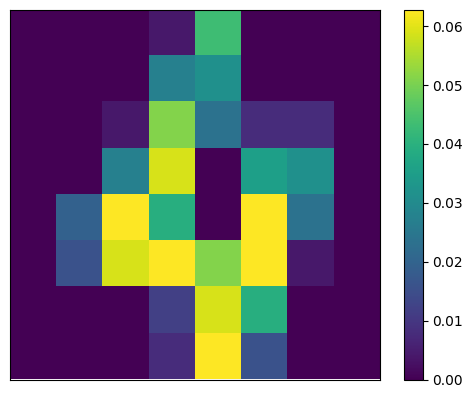

In [3]:
images = load_digits()
mnist_image = images.images[4]

mnist_image = mnist_image/255

plt.imshow(mnist_image)
plt.colorbar()
plt.tick_params(bottom=False, left=False)
plt.tick_params(labelbottom=False, labelleft=False)
plt.show()

In [4]:
n_components = 6
qpca = QPCA(n_components=n_components)
qpca.fit(mnist_image, method='Nelder-Mead', steps=10)

In [5]:
print(qpca.eigenvalue)
print()
print(qpca.components_)

[0.0011414835653785987, 0.000546726055391326, 0.0008103298649453425, 0.00021107324401580319, 6.895771202837876e-05, 7.681948104263431e-05]

[[ 1.03930811e-01  8.39477161e-02  7.56140787e-01  6.10755284e-01
   2.03619985e-02  1.66880605e-02  1.48142186e-01  1.21412727e-01]
 [-9.98050225e-02  2.23646829e-01  3.09176046e-02 -6.92813251e-02
   7.59473475e-01  5.25033420e-01 -2.35269729e-01 -1.62644878e-01]
 [-2.79640625e-02 -7.72488524e-02  5.33467251e-03  1.47366761e-02
   5.97287048e-01 -7.75489505e-01 -1.13943774e-01  1.47939254e-01]
 [-1.03114532e-01  1.20231561e-01  6.42636737e-01 -7.49314540e-01
  -3.38207237e-03  2.11959159e-04  2.10779598e-02 -1.32098493e-03]
 [-5.60010504e-01  4.90055039e-01  7.23586625e-02 -6.33197538e-02
  -6.37610201e-01 -1.52533885e-01  8.23852786e-02  1.97088230e-02]
 [-9.39846582e-02 -1.63976885e-01 -5.80124323e-02 -1.01215433e-01
  -2.11122568e-01 -8.02382202e-01 -1.30316308e-01 -4.95273846e-01]]


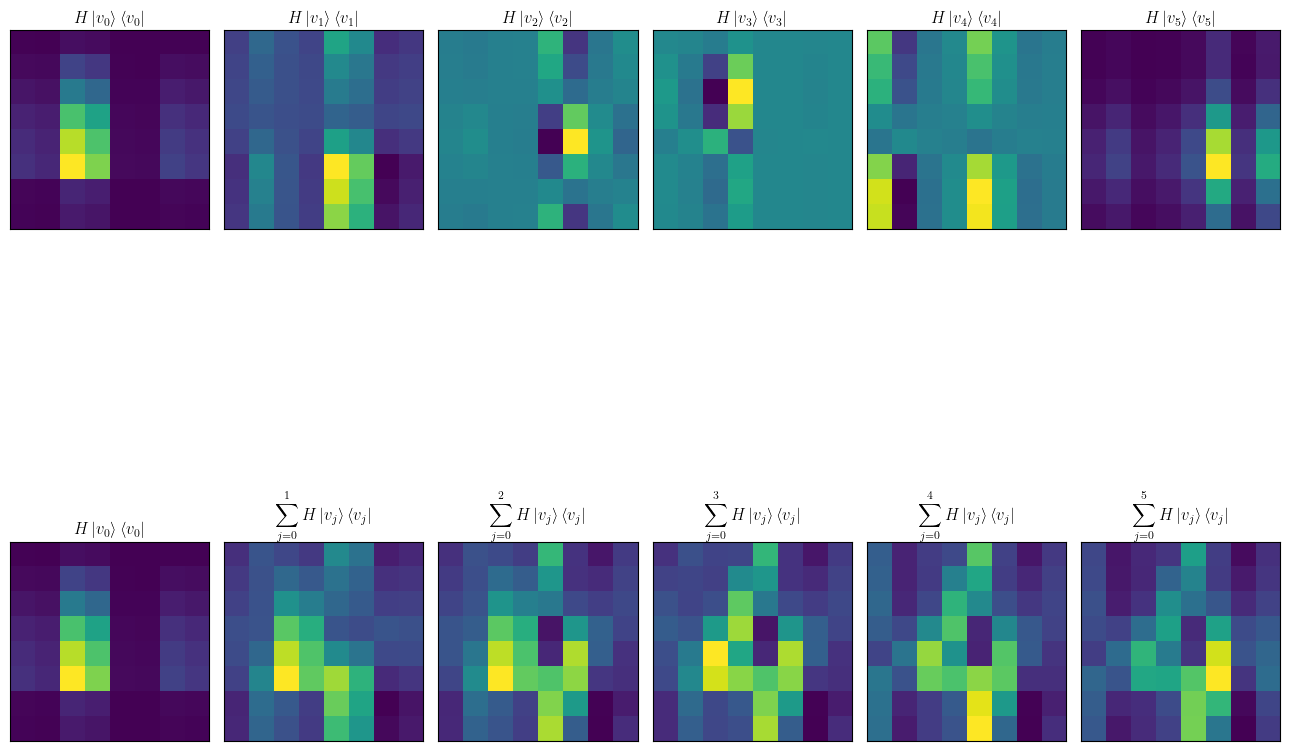

In [6]:
num = n_components

size = int(np.log2(mnist_image.shape[0]))
eigenvector_image = []
eigenvector_sum_image = [np.zeros((2**size, 2**size)) for i in range(num)]

for i in range(num):
    vec = np.outer(qpca.components_[i], qpca.components_[i])
    array = np.dot(mnist_image, vec)
    eigenvector_image.append(array)
    for j in range(num-i):
        eigenvector_sum_image[num-1-j] += array

rc('text', usetex=True)
title = []
for i in range(num):
    title.append(r'$H \left| v_'+str(i)+r' \right\rangle \left\langle v_'+str(i)+r' \right|$')
title.append(r'$H \left| v_0 \right\rangle \left\langle v_0 \right|$')
for i in range(num-1):
    title.append(r'$\displaystyle \sum^'+str(i+1)+r'_{j=0} H \left| v_j \right\rangle \left\langle v_j \right|$')

fig = plt.figure(figsize=(13,13))

for i in range(2*num):
    plt.subplot(2, num, i+1)
    if i < num:
        plt.imshow(eigenvector_image[i])
    else:
        plt.imshow(eigenvector_sum_image[i-num])
    plt.title(title[i])
    plt.tick_params(bottom=False, left=False)
    plt.tick_params(labelbottom=False, labelleft=False)

fig.tight_layout()
plt.show()

In [20]:
from qiskit.utils import algorithm_globals

algorithm_globals.random_seed = 12345

In [21]:
from qiskit_machine_learning.datasets import ad_hoc_data

adhoc_dimension = 2
train_features, train_labels, test_features, test_labels, adhoc_total = ad_hoc_data(
    training_size=20,
    test_size=5,
    n=adhoc_dimension,
    gap=0.3,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

In [22]:
import matplotlib.pyplot as plt
import numpy as np


def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    # A train plot
    ax.scatter(
        # x coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 0],
        # y coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
    )


def plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total):

    plt.figure(figsize=(5, 5))
    plt.ylim(0, 2 * np.pi)
    plt.xlim(0, 2 * np.pi)
    plt.imshow(
        np.asmatrix(adhoc_total).T,
        interpolation="nearest",
        origin="lower",
        cmap="RdBu",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
    )

    # A train plot
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A train")

    # B train plot
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B train")

    # A test plot
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test")

    # B test plot
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.title("Ad hoc dataset")

    plt.show()

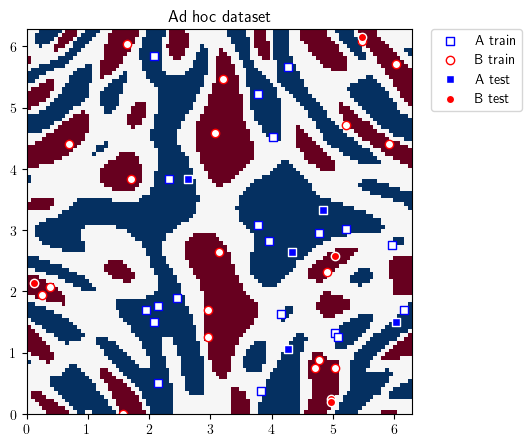

In [23]:
plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total)

In [24]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import Sampler
from qiskit.algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

adhoc_feature_map = ZZFeatureMap(feature_dimension=adhoc_dimension, reps=2, entanglement="linear")

sampler = Sampler()

fidelity = ComputeUncompute(sampler=sampler)

adhoc_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=adhoc_feature_map)

In [25]:
from sklearn.svm import SVC

adhoc_svc = SVC(kernel=adhoc_kernel.evaluate)

adhoc_svc.fit(train_features, train_labels)

adhoc_score_callable_function = adhoc_svc.score(test_features, test_labels)

print(f"Callable kernel classification test score: {adhoc_score_callable_function}")

Callable kernel classification test score: 1.0


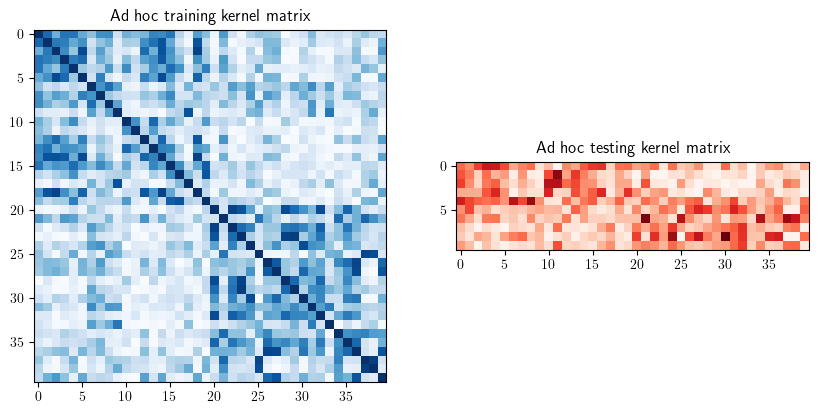

In [26]:
adhoc_matrix_train = adhoc_kernel.evaluate(x_vec=train_features)
adhoc_matrix_test = adhoc_kernel.evaluate(x_vec=test_features, y_vec=train_features)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(
    np.asmatrix(adhoc_matrix_train), interpolation="nearest", origin="upper", cmap="Blues"
)
axs[0].set_title("Ad hoc training kernel matrix")

axs[1].imshow(np.asmatrix(adhoc_matrix_test), interpolation="nearest", origin="upper", cmap="Reds")
axs[1].set_title("Ad hoc testing kernel matrix")

plt.show()

In [27]:
adhoc_svc = SVC(kernel="precomputed")

adhoc_svc.fit(adhoc_matrix_train, train_labels)

adhoc_score_precomputed_kernel = adhoc_svc.score(adhoc_matrix_test, test_labels)

print(f"Precomputed kernel classification test score: {adhoc_score_precomputed_kernel}")

Precomputed kernel classification test score: 1.0


In [28]:
from qiskit_machine_learning.algorithms import QSVC

qsvc = QSVC(quantum_kernel=adhoc_kernel)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC classification test score: {qsvc_score}")

QSVC classification test score: 1.0


In [29]:
print(f"Classification Model                    | Accuracy Score")
print(f"---------------------------------------------------------")
print(f"SVC using kernel as a callable function | {adhoc_score_callable_function:10.2f}")
print(f"SVC using precomputed kernel matrix     | {adhoc_score_precomputed_kernel:10.2f}")
print(f"QSVC                                    | {qsvc_score:10.2f}")

Classification Model                    | Accuracy Score
---------------------------------------------------------
SVC using kernel as a callable function |       1.00
SVC using precomputed kernel matrix     |       1.00
QSVC                                    |       1.00


In [30]:
adhoc_dimension = 2
train_features, train_labels, test_features, test_labels, adhoc_total = ad_hoc_data(
    training_size=25,
    test_size=0,
    n=adhoc_dimension,
    gap=0.6,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

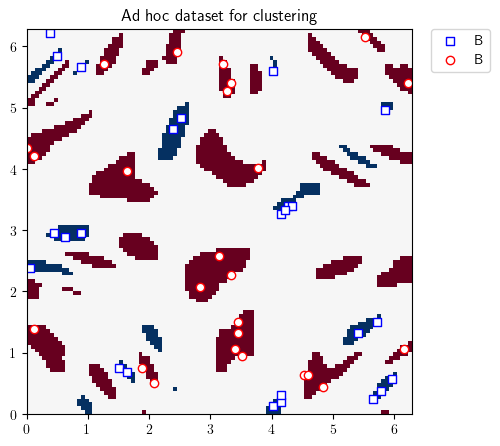

In [31]:
plt.figure(figsize=(5, 5))
plt.ylim(0, 2 * np.pi)
plt.xlim(0, 2 * np.pi)
plt.imshow(
    np.asmatrix(adhoc_total).T,
    interpolation="nearest",
    origin="lower",
    cmap="RdBu",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
)

# A label plot
plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "B")

# B label plot
plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.title("Ad hoc dataset for clustering")

plt.show()

In [32]:
adhoc_feature_map = ZZFeatureMap(feature_dimension=adhoc_dimension, reps=2, entanglement="linear")

adhoc_kernel = FidelityQuantumKernel(feature_map=adhoc_feature_map)

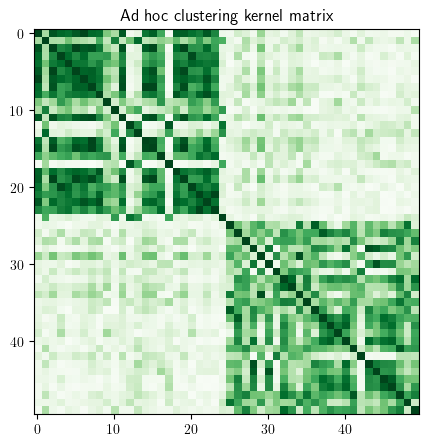

In [33]:
adhoc_matrix = adhoc_kernel.evaluate(x_vec=train_features)

plt.figure(figsize=(5, 5))
plt.imshow(np.asmatrix(adhoc_matrix), interpolation="nearest", origin="upper", cmap="Greens")
plt.title("Ad hoc clustering kernel matrix")
plt.show()

In [34]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import normalized_mutual_info_score

adhoc_spectral = SpectralClustering(2, affinity="precomputed")

cluster_labels = adhoc_spectral.fit_predict(adhoc_matrix)

cluster_score = normalized_mutual_info_score(cluster_labels, train_labels)

print(f"Clustering score: {cluster_score}")

Clustering score: 0.7287008798015754


In [35]:
adhoc_dimension = 2
train_features, train_labels, test_features, test_labels, adhoc_total = ad_hoc_data(
    training_size=25,
    test_size=10,
    n=adhoc_dimension,
    gap=0.6,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

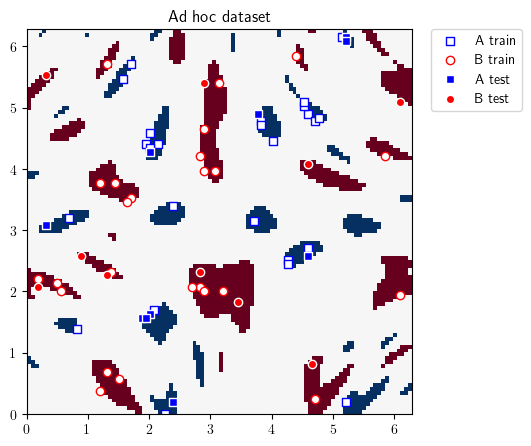

In [36]:
plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total)

In [37]:
feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement="linear")
qpca_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

In [38]:
matrix_train = qpca_kernel.evaluate(x_vec=train_features)
matrix_test = qpca_kernel.evaluate(x_vec=test_features, y_vec=test_features)

In [39]:
from sklearn.decomposition import KernelPCA

kernel_pca_rbf = KernelPCA(n_components=2, kernel="rbf")
kernel_pca_rbf.fit(train_features)
train_features_rbf = kernel_pca_rbf.transform(train_features)
test_features_rbf = kernel_pca_rbf.transform(test_features)

kernel_pca_q = KernelPCA(n_components=2, kernel="precomputed")
train_features_q = kernel_pca_q.fit_transform(matrix_train)
test_features_q = kernel_pca_q.fit_transform(matrix_test)

In [40]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression()
logistic_regression.fit(train_features_q, train_labels)

logistic_score = logistic_regression.score(test_features_q, test_labels)
print(f"Logistic regression score: {logistic_score}")

Logistic regression score: 1.0


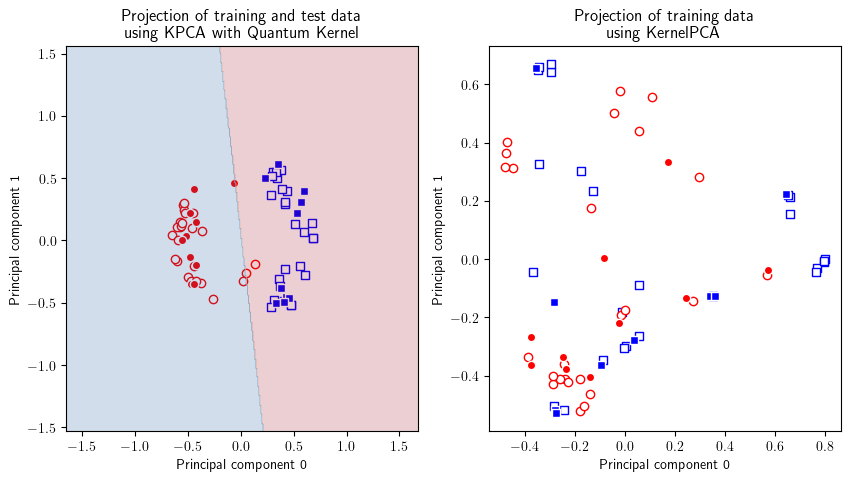

In [42]:
fig, (q_ax, rbf_ax) = plt.subplots(1, 2, figsize=(10, 5))


plot_features(q_ax, train_features_q, train_labels, 0, "s", "w", "b", "A train")
plot_features(q_ax, train_features_q, train_labels, 1, "o", "w", "r", "B train")

plot_features(q_ax, test_features_q, test_labels, 0, "s", "b", "w", "A test")
plot_features(q_ax, test_features_q, test_labels, 1, "o", "r", "w", "A test")

q_ax.set_ylabel("Principal component 1")
q_ax.set_xlabel("Principal component 0")
q_ax.set_title("Projection of training and test data\n using KPCA with Quantum Kernel")

# Plotting the linear separation
h = 0.01  # step size in the mesh

# create a mesh to plot in
x_min, x_max = train_features_q[:, 0].min() - 1, train_features_q[:, 0].max() + 1
y_min, y_max = train_features_q[:, 1].min() - 1, train_features_q[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

predictions = logistic_regression.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
predictions = predictions.reshape(xx.shape)
q_ax.contourf(xx, yy, predictions, cmap=plt.cm.RdBu, alpha=0.2)

plot_features(rbf_ax, train_features_rbf, train_labels, 0, "s", "w", "b", "A train")
plot_features(rbf_ax, train_features_rbf, train_labels, 1, "o", "w", "r", "B train")
plot_features(rbf_ax, test_features_rbf, test_labels, 0, "s", "b", "w", "A test")
plot_features(rbf_ax, test_features_rbf, test_labels, 1, "o", "r", "w", "A test")

rbf_ax.set_ylabel("Principal component 1")
rbf_ax.set_xlabel("Principal component 0")
rbf_ax.set_title("Projection of training data\n using KernelPCA")
plt.show()